In [2]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.8 MB/s eta 0:00:00


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import seaborn as sns

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical

# Load dataset
data = pd.read_csv('/content/NF-ToN-IoT new.csv')




In [29]:
data.columns

Index(['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES',
       'OUT_BYTES', 'IN_PKTS', 'OUT_PKTS', 'TCP_FLAGS',
       'FLOW_DURATION_MILLISECONDS', 'Label'],
      dtype='object')

In [5]:
#data.rename(columns={'Label_encoded': 'Label'}, inplace=True)

In [41]:
#data.drop(['IPV4_SRC_ADDR','IPV4_DST_ADDR', 'Attack' ],axis=1,inplace=True)

In [30]:
data.describe()

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.354957e+04,5.225557e+03,6.981512e+00,2.536915e+01,1.835456e+03,3.551047e+03,2.247707e+01,1.364674e+01,2.264828e+01,7.967647e+03,8.286751e-01
std,1.546455e+04,1.456097e+04,3.234854e+00,3.814229e+01,2.040705e+05,1.267781e+05,3.308759e+03,1.668110e+03,8.375267e+00,1.370583e+05,3.767928e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.800000e+01,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.794600e+04,8.000000e+01,6.000000e+00,7.000000e+00,2.080000e+02,1.120000e+02,2.000000e+00,2.000000e+00,1.900000e+01,2.900000e+01,1.000000e+00
50%,4.665800e+04,8.000000e+01,6.000000e+00,7.000000e+00,4.910000e+02,2.163000e+03,5.000000e+00,5.000000e+00,2.700000e+01,1.880000e+02,1.000000e+00
75%,5.441000e+04,4.430000e+02,6.000000e+00,7.178000e+00,5.840000e+02,3.752000e+03,5.000000e+00,6.000000e+00,2.700000e+01,4.590000e+02,1.000000e+00
max,6.553500e+04,6.553400e+04,5.800000e+01,2.510000e+02,7.941590e+07,7.016518e+07,1.221043e+06,1.349068e+06,2.190000e+02,4.294849e+06,1.000000e+00


In [31]:
data

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label
0,63318,443,6,91.00,181,165,2,1,24,327,0
1,57442,15600,17,0.00,63,0,1,0,0,0,0
2,57452,15600,17,0.00,63,0,1,0,0,0,0
3,138,138,17,10.16,472,0,2,0,0,0,0
4,51989,15600,17,0.00,63,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1048570,34848,443,6,91.00,112,60,2,1,18,0,1
1048571,34850,443,6,91.00,112,60,2,1,18,0,1
1048572,34852,443,6,91.00,112,60,2,1,18,0,1
1048573,34854,443,6,91.00,112,60,2,1,18,1,1


In [34]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import KMeansSMOTE
import pandas as pd
from sklearn.preprocessing import StandardScaler
# Splitting the dataset into a 70-30 train-test split
def simple_split(data):
    train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)
    return train_data, test_data

# Assuming 'data' is a Pandas DataFrame
# Apply the splitting function
train_data, test_data = simple_split(data)






In [35]:
train_data

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,FLOW_DURATION_MILLISECONDS,Label
618349,49838,80,6,7.0,849,696,5,4,27,334,1
766114,43659,15600,17,0.0,63,0,1,0,0,0,0
1045426,47067,53,17,5.0,67,67,1,1,0,0,1
415737,55138,80,6,7.0,535,3812,6,7,27,122,1
473060,43338,80,6,7.0,523,3812,5,7,27,229,1
...,...,...,...,...,...,...,...,...,...,...,...
259178,42234,80,6,7.0,485,3812,5,7,27,196,1
365838,36052,80,6,7.0,514,2239,5,6,27,103,1
131932,53636,80,6,7.0,511,696,5,4,27,225,1
671155,42324,80,6,7.0,762,696,5,4,27,260,1


In [36]:


# Remove rows that contain NaN values
train_data = train_data.dropna()

# Display the cleaned DataFrame
print(train_data)


         L4_SRC_PORT  L4_DST_PORT  PROTOCOL  L7_PROTO  IN_BYTES  OUT_BYTES  \
618349         49838           80         6       7.0       849        696   
766114         43659        15600        17       0.0        63          0   
1045426        47067           53        17       5.0        67         67   
415737         55138           80         6       7.0       535       3812   
473060         43338           80         6       7.0       523       3812   
...              ...          ...       ...       ...       ...        ...   
259178         42234           80         6       7.0       485       3812   
365838         36052           80         6       7.0       514       2239   
131932         53636           80         6       7.0       511        696   
671155         42324           80         6       7.0       762        696   
121958         49078           53        17       5.0       130        146   

         IN_PKTS  OUT_PKTS  TCP_FLAGS  FLOW_DURATION_MILLISECON

In [37]:
# Remove rows that contain NaN values
test_data = test_data.dropna()

# Display the cleaned DataFrame
print(test_data)

        L4_SRC_PORT  L4_DST_PORT  PROTOCOL  L7_PROTO  IN_BYTES  OUT_BYTES  \
781974        60077           53        17       5.0       126        523   
937737        59180          443         6      91.0       874       4313   
907828        54588           80         6       7.0       412         60   
784628        58511         9197         6       7.0       396       2074   
662460        38220           80         6       7.0       479        696   
...             ...          ...       ...       ...       ...        ...   
49012         53156           80         6       7.0       112         60   
468748           80        46600         6       7.0     10664        453   
105662        36492           80         6       7.0       216       3708   
165822        54896           80         6       7.0       508       2239   
681610        38252           80         6       7.0       542       2239   

        IN_PKTS  OUT_PKTS  TCP_FLAGS  FLOW_DURATION_MILLISECONDS  Label  
7

In [38]:
train_data['Label'].value_counts()

,count
Label,
1,608101
0,125901


Echo State Network

In [39]:

# Manual Echo State Network Implementation
class ManualESN:
    def __init__(self, input_dim, reservoir_size, spectral_radius=0.95, sparsity=0.1):
        self.input_dim = input_dim
        self.reservoir_size = reservoir_size
        self.spectral_radius = spectral_radius
        self.sparsity = sparsity
        self.W_in = np.random.uniform(-1, 1, (reservoir_size, input_dim))
        self.W = np.random.uniform(-1, 1, (reservoir_size, reservoir_size))
        self.W[np.random.rand(*self.W.shape) > sparsity] = 0
        max_eig = max(abs(np.linalg.eigvals(self.W)))
        self.W *= spectral_radius / max_eig
        self.state = np.zeros(reservoir_size)

    def update(self, input_data):
        # Convert input_data to a NumPy array with float64 dtype
        input_data = np.array(input_data, dtype=np.float64)
        self.state = np.tanh(np.dot(self.W_in, input_data) + np.dot(self.W, self.state))
        return self.state

    def fit_transform(self, X):
        states = []
        for x in X:
            states.append(self.update(x))
        return np.array(states)


# DNN Training
class ESN_DNN:
    def __init__(self, reservoir_size=200, spectral_radius=0.95):
        self.esn = ManualESN(input_dim=train_data.drop('Label', axis=1).shape[1],
                             reservoir_size=reservoir_size, spectral_radius=spectral_radius)
        self.dnn = None

    def train(self, X, y):
        esn_output = self.esn.fit_transform(X)
        self.dnn = Sequential([
            Dense(64, activation='relu', input_shape=(esn_output.shape[1],)),
            Dropout(0.15),
            Dense(64, activation='relu'),
            Dropout(0.15),
            Dense(128, activation='relu'),
            Dropout(0.25),
            Dense(32, activation='relu'),
            Dense(len(np.unique(y)), activation='softmax')
        ])
        self.dnn.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        self.dnn.fit(esn_output, y, epochs=15, batch_size=64, verbose=1)

    def predict(self, X):
        esn_output = self.esn.fit_transform(X)
        return self.dnn.predict(esn_output)

# Train and evaluate the model
esn_dnn_model = ESN_DNN(reservoir_size=250, spectral_radius=0.95)
esn_dnn_model.train(train_data.drop('Label', axis=1).values, train_data['Label'].values)




/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.9638 - loss: 0.1364
Epoch 2/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - accuracy: 0.9666 - loss: 0.1201
Epoch 3/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 81s 4ms/step - accuracy: 0.9670 - loss: 0.1185
Epoch 4/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 84s 4ms/step - accuracy: 0.9673 - loss: 0.1188
Epoch 5/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 79s 4ms/step - accuracy: 0.9678 - loss: 0.1177
Epoch 6/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 42s 4ms/step - accuracy: 0.9676 - loss: 0.1172
Epoch 7/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 84s 4ms/step - accuracy: 0.9676 - loss: 0.1183
Epoch 8/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 82s 4ms/step - accuracy: 0.9677 - loss: 0.1183
Epoch 9/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 85s 4ms/step - accuracy: 0.9675 - loss: 0.1195
Epoch 10/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 77s 4ms/step - accuracy: 0.9672 - loss: 0.1202
Epoch 11/15
11469/11469 ━━━━━━━━━━━━━━━━━━━━ 83s 4ms/step - accuracy: 0.9678 - loss: 0.11

9831/9831 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.81      0.90     53746
           1       0.96      1.00      0.98    260827

    accuracy                           0.97    314573
   macro avg       0.98      0.91      0.94    314573
weighted avg       0.97      0.97      0.97    314573



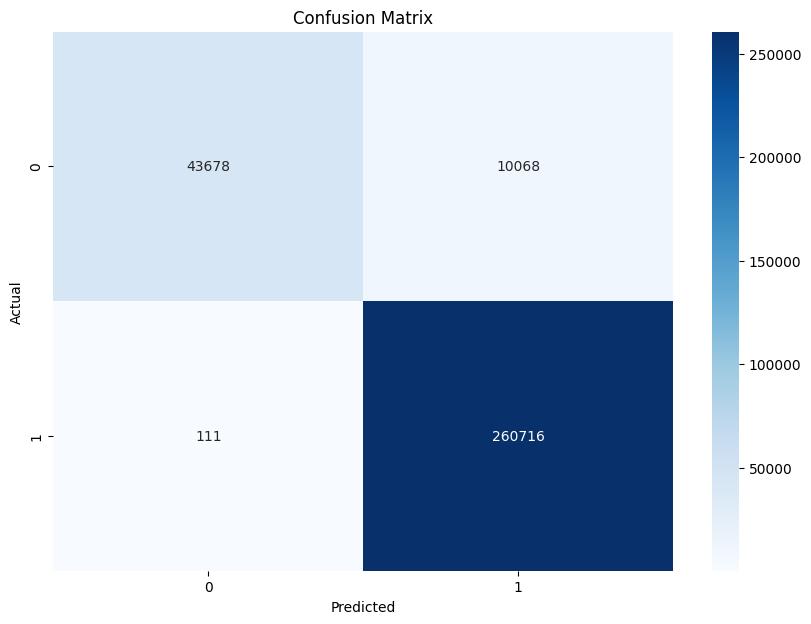

In [40]:
# Prediction
y_pred = esn_dnn_model.predict(test_data.drop('Label', axis=1).values)
y_pred = np.argmax(y_pred, axis=1)

# Evaluation
print("Classification Report:\n")
print(classification_report(test_data['Label'].values, y_pred))

# Plot classification report
conf_matrix = confusion_matrix(test_data['Label'].values, y_pred)
plt.figure(figsize=(10, 7))
plt.title("Confusion Matrix")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(test_data['Label']),
            yticklabels=np.unique(test_data['Label']))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prediction for Test Data
y_test_true = test_data['Label'].values
y_test_pred_prob = esn_dnn_model.predict(test_data.drop('Label', axis=1).values)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Prediction for Train Data
y_train_true = train_data['Label'].values
y_train_pred_prob = esn_dnn_model.predict(train_data.drop('Label', axis=1).values)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

def evaluate_metrics(y_true, y_pred, y_pred_prob, average='macro'):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average),
        "F1 Score": f1_score(y_true, y_pred, average=average),
        # Select the probability for the positive class (class 1)
        "AUC-ROC": roc_auc_score(y_true, y_pred_prob[:, 1], multi_class='ovr')
    }
    return metrics


# Evaluate for Test Data
test_metrics = evaluate_metrics(y_test_true, y_test_pred, y_test_pred_prob)
print("Test Data Metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Evaluate for Train Data
train_metrics = evaluate_metrics(y_train_true, y_train_pred, y_train_pred_prob)
print("\nTrain Data Metrics:")
for key, value in train_metrics.items():
    print(f"{key}: {value:.4f}")

# Classification Report
print("\nClassification Report for Test Data:\n")
print(classification_report(y_test_true, y_test_pred))






9831/9831 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step
22938/22938 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step
Test Data Metrics:
Accuracy: 0.9676
Precision: 0.9801
Recall: 0.9061
F1 Score: 0.9382
AUC-ROC: 0.9711

Train Data Metrics:
Accuracy: 0.9682
Precision: 0.9804
Recall: 0.9082
F1 Score: 0.9397
AUC-ROC: 0.9722

Classification Report for Test Data:

              precision    recall  f1-score   support

           0       1.00      0.81      0.90     53746
           1       0.96      1.00      0.98    260827

    accuracy                           0.97    314573
   macro avg       0.98      0.91      0.94    314573
weighted avg       0.97      0.97      0.97    314573

